#ML project

# **Amazon Sales Machine Learning Analysis**

This project explores whether machine learning models can predict product sales quantity using product pricing, discounts, ratings, and customer attributes.

Models used:
• Linear Regression
• Random Forest

Despite feature engineering, model performance remained weak, suggesting that the dataset lacks strong predictive relationships between features and the target variable.

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

df = pd.read_csv('amazon_sales_dataset.csv')
df.head()
#df.head(10) can do for specific count of datasets to be show.


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  object 
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  object 
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  object 
 8   payment_method    50000 non-null  object 
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 5.0+ MB


In [75]:
df.describe()

,order_id,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,2986.848740,252.507260,13.340700,2.999400,2.996316,249.329280,218.886566,657.331475
std,14433.901067,1156.374535,143.025544,9.850694,1.415401,1.154295,144.251981,127.317681,526.223968
min,1.000000,1000.000000,5.010000,0.000000,1.000000,1.000000,0.000000,3.530000,3.840000
25%,12500.750000,1983.000000,127.840000,5.000000,2.000000,2.000000,125.000000,109.680000,240.320000
50%,25000.500000,2983.000000,252.970000,10.000000,3.000000,3.000000,250.000000,215.805000,505.410000
75%,37500.250000,3989.000000,376.335000,20.000000,4.000000,4.000000,374.000000,322.702500,968.970000
max,50000.000000,4999.000000,499.990000,30.000000,5.000000,5.000000,499.000000,499.910000,2499.550000


In [76]:
df.columns


Index(['order_id', 'order_date', 'product_id', 'product_category', 'price',
       'discount_percent', 'quantity_sold', 'customer_region',
       'payment_method', 'rating', 'review_count', 'discounted_price',
       'total_revenue'],
      dtype='object')

In [77]:
X = df[['price','discount_percent','product_category','customer_region','payment_method','rating','review_count']]
y = df['quantity_sold']

X.head()


,price,discount_percent,product_category,customer_region,payment_method,rating,review_count
0,128.75,10,Books,North America,UPI,3.5,443
1,302.60,20,Fashion,Asia,Credit Card,3.7,475
2,495.80,20,Sports,Europe,UPI,4.4,183
3,371.95,15,Books,Middle East,UPI,5.0,212
4,201.68,0,Beauty,Middle East,UPI,4.6,308


In [78]:
y.head()

,quantity_sold
0,4
1,5
2,2
3,4
4,4


In [79]:
X['product_category'].unique()

array(['Books', 'Fashion', 'Sports', 'Beauty', 'Electronics',
       'Home & Kitchen'], dtype=object)

In [80]:
X['customer_region'].unique()

array(['North America', 'Asia', 'Europe', 'Middle East'], dtype=object)

In [81]:
X['payment_method'].unique()

array(['UPI', 'Credit Card', 'Wallet', 'Cash on Delivery', 'Debit Card'],
      dtype=object)

In [82]:
X = pd.get_dummies(X,columns=['product_category','customer_region','payment_method'])
X.head()

,price,discount_percent,rating,review_count,product_category_Beauty,product_category_Books,product_category_Electronics,product_category_Fashion,product_category_Home & Kitchen,product_category_Sports,customer_region_Asia,customer_region_Europe,customer_region_Middle East,customer_region_North America,payment_method_Cash on Delivery,payment_method_Credit Card,payment_method_Debit Card,payment_method_UPI,payment_method_Wallet
0,128.75,10,3.5,443,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False
1,302.60,20,3.7,475,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False
2,495.80,20,4.4,183,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False
3,371.95,15,5.0,212,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False
4,201.68,0,4.6,308,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False


#**Train-Test-Split**

In [83]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [84]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40000, 19)
(10000, 19)
(40000,)
(10000,)


#**Linear Regression**

In [85]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred[:10])

[2.99217469 2.98677779 2.98191283 3.03059381 2.9891684  3.00047655
 3.03608859 2.97744038 2.99892847 2.98978934]


In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 1.204894090245541
MSE: 1.9996259167483794
R2 Score: -0.000514323917827797


In [87]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

MAE: 1.2458670000000003
MSE: 2.08043495
R2: -0.04094718418084686


Right now the Models is performing bad so we have to enhance the data and do feature engineering.

In [89]:
df['order_date'] = pd.to_datetime(df['order_date'])

df['order_month'] = df['order_date'].dt.month
df['order_day'] = df['order_date'].dt.day
df['order_weekday'] = df['order_date'].dt.weekday

In [90]:
X = df[['price','discount_percent','rating','review_count',
        'order_month','order_day','order_weekday',
        'product_category','customer_region','payment_method']]


In [91]:
X = pd.get_dummies(X, columns=['product_category','customer_region','payment_method'])

#**Train-Test-Split** (again)

In [92]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [93]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(40000, 22)
(10000, 22)
(40000,)
(10000,)


#**Linear Regression**(again)

In [94]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(y_pred[:10])

[2.9759317  3.01300978 2.99259355 3.04417979 3.02666617 2.97952603
 3.02665607 2.98636133 2.97559428 2.99932232]


In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 1.2057059150881668
MSE: 1.9995556878114584
R2 Score: -0.0004791848166816326


In [96]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_

In [97]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 1.2057059150881668
MSE: 1.9995556878114584
R2 Score: -0.0004791848166816326


In [98]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(feature_importance)

                            feature  importance
0                             price    0.194319
3                      review_count    0.173434
2                            rating    0.121395
5                         order_day    0.107927
4                       order_month    0.078094
6                     order_weekday    0.061526
1                  discount_percent    0.057341
14           customer_region_Europe    0.014560
15      customer_region_Middle East    0.014264
16    customer_region_North America    0.014172
13             customer_region_Asia    0.014082
7           product_category_Beauty    0.014041
10         product_category_Fashion    0.014041
11  product_category_Home & Kitchen    0.013868
21            payment_method_Wallet    0.013863
17  payment_method_Cash on Delivery    0.013859
9      product_category_Electronics    0.013772
12          product_category_Sports    0.013594
19        payment_method_Debit Card    0.013557
8            product_category_Books    0

Still the model is performing bad, i want to see if anything helps to improve it or not

In [99]:
df['quantity_sold'].value_counts()

,count
quantity_sold,
1,10060
3,10026
5,10004
4,9996
2,9914


**VISUALIZATION**

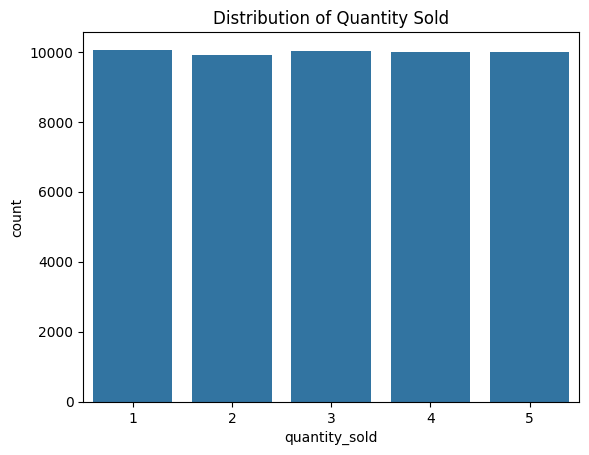

In [100]:

sns.countplot(x='quantity_sold', data=df)

plt.title("Distribution of Quantity Sold")
plt.show()

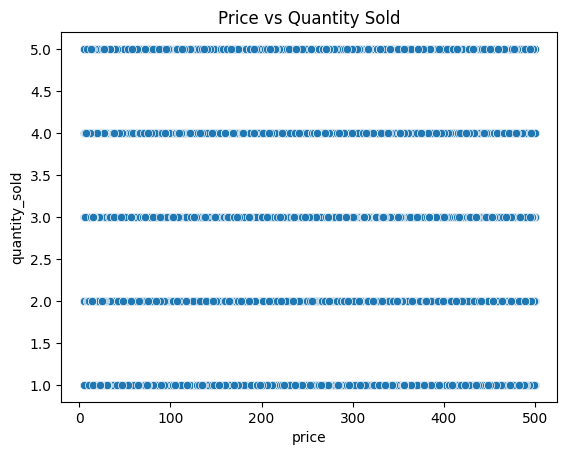

In [101]:
sns.scatterplot(x='price', y='quantity_sold', data=df)

plt.title("Price vs Quantity Sold")
plt.show()

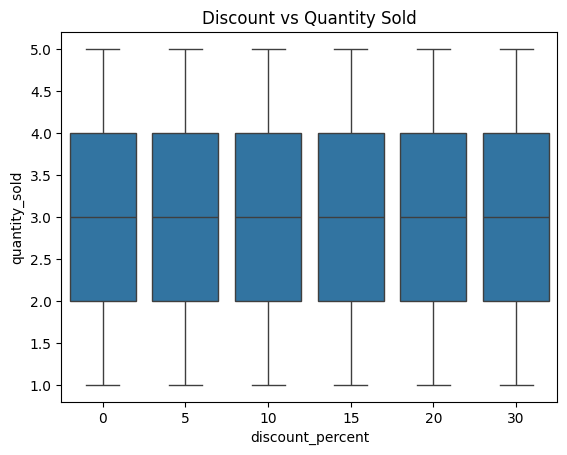

In [102]:
sns.boxplot(x='discount_percent', y='quantity_sold', data=df)

plt.title("Discount vs Quantity Sold")
plt.show()

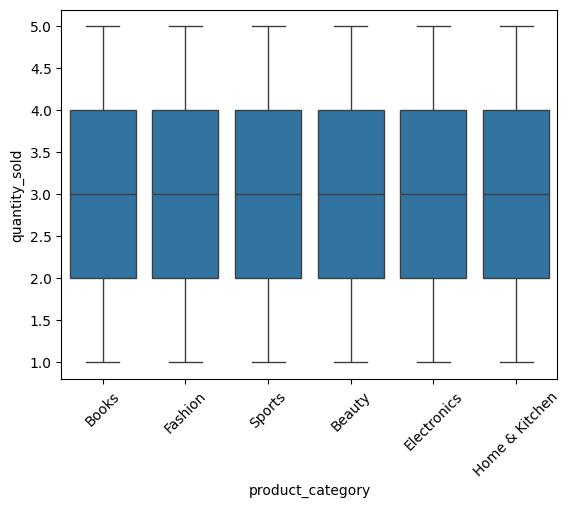

In [103]:
sns.boxplot(x='product_category', y='quantity_sold', data=df)

plt.xticks(rotation=45)
plt.show()

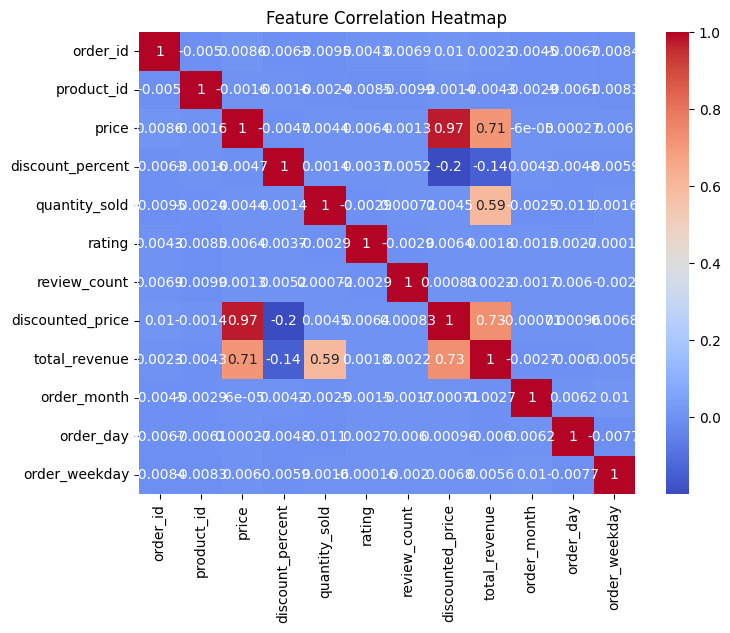

In [104]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()


In [105]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [1.2049, 1.2458],
    "MSE": [1.9996, 2.0804],
    "R2": [-0.0005, -0.0409]
})

print(results)

               Model     MAE     MSE      R2
0  Linear Regression  1.2049  1.9996 -0.0005
1      Random Forest  1.2458  2.0804 -0.0409


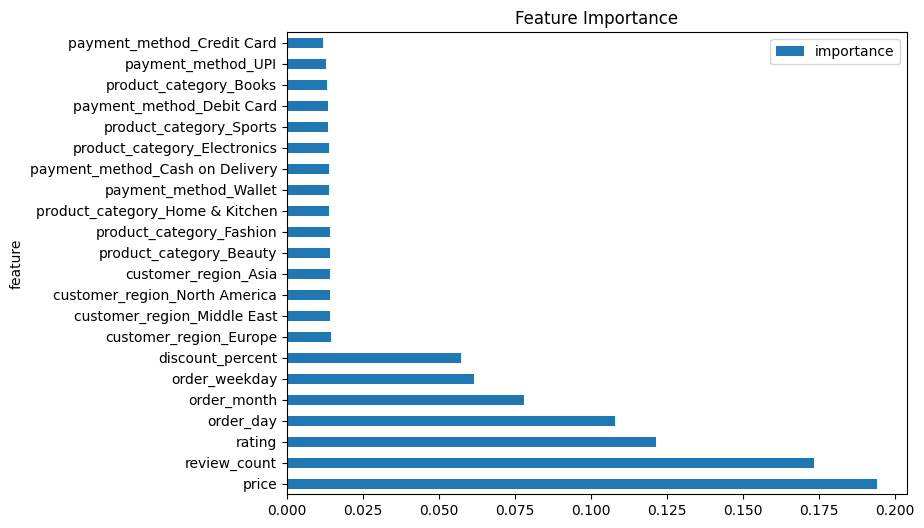

In [106]:
feature_importance.plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance")
plt.show()

In [107]:


joblib.dump(model, "sales_prediction_model.pkl")

['sales_prediction_model.pkl']

## Conclusion

Machine learning models were used to predict product sales quantity using
price, discount, ratings, and customer attributes.

Both Linear Regression and Random Forest models produced very low predictive
performance (R² ≈ 0), indicating that the dataset does not contain strong
relationships between the available features and the target variable.

Exploratory data analysis revealed that the target variable (quantity_sold)
is almost uniformly distributed, which explains why the models struggle to
learn meaningful patterns.

This highlights an important machine learning insight: model performance
depends heavily on the presence of informative features in the dataset.